<a href="https://colab.research.google.com/github/Jelladotexe/stat131/blob/main/statblahblah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy import stats
ls = [300,250,150,120,240,180,250]
x_bar = np.sum(ls) / 7
print(x_bar)

212.85714285714286


In [2]:
stats.t.isf(0.05/2,df=12)

np.float64(2.178812829663418)

In [3]:
stats.t.ppf(0.05/2,df=12)

np.float64(-2.178812829663418)

In [4]:
(1.5 + stats.norm.ppf(0.1/2)*0.8 / np.sqrt(150), 1.5+stats.norm.isf(0.1/2)* 0.8 / np.sqrt(150))

(np.float64(1.3925586109974042), np.float64(1.6074413890025958))

In [5]:
ls = [200,150,120,300,250,170,220,180,310,400]
x_bar = np.mean(ls)
s = np.std(ls,ddof=1)

print((x_bar + stats.t.ppf(0.05/2,df=9)*s/np.sqrt(10)),"<= μ <=",(x_bar+stats.t.isf(0.05/2, df=9)*s/np.sqrt(10)))

168.6477472160666 <= μ <= 291.3522527839334


In [6]:
p = 65/125
print((p+stats.norm.ppf(0.1/2)*np.sqrt(p*(1-p)/125)), "<= P <=",(p+stats.norm.isf(0.1/2)*np.sqrt(p*(1-p)/125)))


0.44649878117243413 <= P <= 0.5935012188275659


In [7]:
scores = [40, 64, 49, 41, 57, 49, 61, 36, 72, 42, 47, 80, 57, 62, 26, 40, 53, 63, 42, 44, 50, 70, 92, 55, 60, 42, 63, 54, 24, 78]
np.var(scores,ddof=1)

np.float64(238.66781609195402)

In [8]:
ls = [40, 64,49, 41, 57, 49, 61, 36, 72, 42, 47, 80, 57, 62, 26, 40, 53, 63, 42, 44, 50, 70, 92, 55, 60, 42, 63, 54, 24, 78]
s2 = np.var(ls,ddof=1)
n = 30
print((n-1)*s2/stats.chi2.isf(0.05/2, df=n-1),"< σ**2 <",(n-1)*s2/stats.chi2.ppf(0.05/2, df=n-1))



151.37840431492018 < σ**2 < 431.31649176004277


In [9]:
n = 8
a = (n-1)*(2.4**2)/stats.chi2.isf(0.05/2,df=n-1)
b = (n-1)*(2.4**2)/stats.chi2.ppf(0.05/2, df=n-1)
print(a,"< σ**2 <",b)

2.517991229277205 < σ**2 < 23.859835105009978


In [10]:
conv = [17,25,23,18,11,14,21,10,27,24,12,27,16,28]
np.percentile(conv,25, method='linear')

np.float64(14.5)

In [11]:
conv = [17,25,23,18,11,14,21,10,27,24,12,27,16,28]
np.percentile(conv,50, method='linear')

np.float64(19.5)

In [12]:
conv = [17,25,23,18,11,14,21,10,27,24,12,27,16,28]
np.percentile(conv,75, method='linear')

np.float64(24.75)

In [13]:
# 9.2
ls = [4.17, 5.72, 6.23, 5.65, 6.59, 6.47, 4.67, 6.25, 3.85, 7.02, 5.24,4.69, 5.75, 5.05, 5.33, 5.45, 6.32, 4.7 , 5.63, 6.22, 6.73, 4.81,4.29, 4.68, 6.13, 5.44, 6.06, 7.54, 7.28, 5.18]
n = 30
u0 = 5.85
x_bar = sum(ls)/n
s = np.std(ls, ddof=1)
z_cal = (x_bar - u0) / (s/np.sqrt(n))
z_crit = stats.norm.isf(0.05)
p_val = stats.norm.sf(z_cal)
print(f"z_cal = {z_cal} z_crit = {z_crit} p_val = {p_val}")
if(z_crit > z_cal and p_val > 0.05):
    print("ยอมรับ H0 ปฎิเสธ H1")



z_cal = -1.2418471165676772 z_crit = 1.6448536269514729 p_val = 0.8928535125403201
ยอมรับ H0 ปฎิเสธ H1


In [14]:
# 9.2
from statsmodels.stats.weightstats import ztest
z_cal, p_val = ztest(x1=ls, value = 5.85, alternative="larger")
print(f"z_cal = {z_cal} p_val = {p_val}")

z_cal = -1.2418471165676772 p_val = 0.8928535125403201


In [15]:
# 9.3
ls = [164, 161, 158, 170, 161, 152, 158, 169, 152, 160]
x_bar = sum(ls)/10
u0 = 160
s = np.std(ls,ddof=1)
t_cal = (x_bar-u0 )/ (s/np.sqrt(10))
t_crit = stats.t.isf(0.05/2, df=10-1)
p_val = 2*stats.t.sf(t_cal,df=10-1)

print(f"t_cal = {t_cal} t_crit = {t_crit} p_val = {p_val}")
if(t_crit>t_cal and p_val > 0.05):
    print("ยอมรับ H0 ปฎิเสธ H1")

t_cal = 0.260132990857236 t_crit = 2.2621571628540997 p_val = 0.8006146644674419
ยอมรับ H0 ปฎิเสธ H1


In [16]:
# 9.3
t_cal, p_val = stats.ttest_1samp(a=ls, popmean=u0, alternative='two-sided')
print(f"t_cal = {t_cal} p_val = {p_val}")

t_cal = 0.260132990857236 p_val = 0.8006146644674419


In [17]:
# 9.4
ls = [0.68270656, 0.98570868, 0.4025518 , 0.42397662, 0.92248197, 0.59625324, 0.61194484, 0.98900446, 0.30617307, 0.36091738, 0.21453245, 0.64698407]
n = 12
x_bar = np.mean(ls)
u0 = 1
s = np.std(ls, ddof=1)

t_cal = (x_bar-u0) / (s/np.sqrt(n))
t_crit_left = stats.t.ppf(0.05/2, df=n-1)
t_crit_right = stats.t.isf(0.05/2, df=n-1)
p_val = 2*stats.t.sf(np.abs(t_cal), df=11)

print(f"t_cal = {t_cal} t_crit_left = {t_crit_left} t_crit_right = {t_crit_right} p_val = {p_val}")
if(t_crit_left>t_cal>t_crit_right and p_val>0.05):
      print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")


t_cal = -5.281782935072749 t_crit_left = -2.200985160082949 t_crit_right = 2.200985160082949 p_val = 0.0002595718418202789
ปฎิเสธ H0 ยอมรับ H1


In [18]:
# 9.4
t_cal,p_val = stats.ttest_1samp(a=ls,popmean=u0,alternative='two-sided')
print(t_cal, p_val)

-5.281782935072749 0.0002595718418202789


In [19]:
# 9.5
lsa = [5.47, 3.91, 5.81, 4.11, 6.86, 4.52, 5.24, 4.96, 5.64, 6.73]
lsb = [6.04, 7.93, 7.53, 7.69, 6.90 , 6.68, 6.00, 7.63, 5.86, 8.26]
n = 10
u1 = 2
u2 = 2

x_bar1 = np.mean(lsa)
x_bar2 = np.mean(lsb)
s_1 = np.std(lsa, ddof=1)
s_2 = np.std(lsb, ddof=1)
s2p = ((n-1)*s_1**2 + (n-1)*s_2**2) / (n+n-2)

t_cal = ((x_bar1-x_bar2) - (u1-u2)) / (np.sqrt(s2p*(1/n + 1/n)))
t_crit_left = stats.t.ppf(0.05/2 , df=n+n-2)
t_crit_right = stats.t.isf(0.05/2, df=n+n-2)
p_val = 2*stats.t.sf(np.abs(t_cal), df=n+n-2)
print(f"t_cal = {t_cal} t_crit_left = {t_crit_left} t_crit_right = {t_crit_right}, p_val = {p_val}")

if(p_val>0.05):
    print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")

t_cal = -4.113250934483508 t_crit_left = -2.10092204024096 t_crit_right = 2.10092204024096, p_val = 0.0006526941228295857
ปฎิเสธ H0 ยอมรับ H1


In [20]:
from scipy import stats
t_cal, p_val = stats.ttest_ind(a=lsa, b=lsb, alternative='two-sided', equal_var=True)
print(f"t_cal = {t_cal} p_val = {p_val}")

t_cal = -4.113250934483508 p_val = 0.0006526941228295857


In [21]:
# 9.6
x_bar1 = 55
x_bar2 = 62
sd1 = 15
sd2 = 10
n = 50

z_cal = ((x_bar1-x_bar2) - 0) / (np.sqrt((sd1**2/n )+ (sd2**2/n)))
z_crit = stats.norm.ppf(0.05)
p_val = stats.norm.cdf(z_cal)
print(f"z_cal = {z_cal} z_crit = {z_crit} p_val = {p_val}")
if(p_val > 0.05):
    print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")

z_cal = -2.745625891934577 z_crit = -1.6448536269514729 p_val = 0.003019779524328408
ปฎิเสธ H0 ยอมรับ H1


In [22]:
# 9.7
lsa = [17.53, 20.60, 17.62, 28.93, 27.10]
lsb = [15.59, 14.76, 13.32, 12.45, 12.79]
n = 5
x_bar1 = np.mean(lsa)
x_bar2 = np.mean(lsb)
s1 = np.std(lsa, ddof=1)
s2 = np.std(lsb, ddof=1)

t_cal = (x_bar1-x_bar2) / (np.sqrt((s1**2/n) + (s2**2/n)))
df = ((s1**2/n) + (s2**2/n))**2 / ((s1**2/n)**2/(n-1)) + ((s2**2/n)**2/(n-1))
t_crit_left = stats.t.ppf(0.01/2, df=df)
t_crit_right = stats.t.isf(0.01/2, df=df)
p_val = 2*stats.t.sf(abs(t_cal), df=df)
print(f"t_cal = {t_cal} df = {df} t_crit_left = {t_crit_left} t_crit_right = {t_crit_right} p_val = {p_val}")
if(p_val > 0.01):
    print("ยอมรับ H0 ปฎิเสธ H1")


t_cal = 3.4754503043912526 df = 4.550906522091193 t_crit_left = -4.244869907589354 t_crit_right = 4.244869907589354 p_val = 0.02066824079816786
ยอมรับ H0 ปฎิเสธ H1


In [23]:
# 9.7
from scipy import stats
t_cal, p_val = stats.ttest_ind(a=lsa, b=lsb, alternative='two-sided', equal_var=False)
print(t_cal, p_val)

3.4754503043912526 0.021042340296756768


In [24]:
# 9.8
n = 100
p_hat = 60/n
p0 = 0.5
z_cal = (p_hat-p0) / (np.sqrt(p0*(1-p0)/n))
z_crit = stats.norm.isf(0.05)
p_val = stats.norm.sf(z_cal)
print(f"z_cal = {z_cal} z_crit = {z_crit} p_val = {p_val}")

if(p_val > 0.05):
  print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")

z_cal = 1.9999999999999996 z_crit = 1.6448536269514729 p_val = 0.022750131948179216
ปฎิเสธ H0 ยอมรับ H1


In [25]:
# 9.8
from statsmodels.stats.proportion import proportions_ztest
z_cal, p_val = proportions_ztest(count=60, nobs=100, value=0.5,alternative='larger', prop_var=0.5)
print(f"z_cal = {z_cal} p_val = {p_val}")

z_cal = 1.9999999999999996 p_val = 0.022750131948179216


In [26]:
# 9.9
n = 36
p_hat = 9/36
p0 = 1/5
z_cal = (p_hat - p0 )/ (np.sqrt(p0*(1-p0)/n))
z_crit = stats.norm.isf(0.01)
p_val = stats.norm.sf(z_cal)
print(f"z_cal = {z_cal} z_crit = {z_crit} p_val = {p_val}")
if(p_val > 0.01):
  print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")

z_cal = 0.7499999999999997 z_crit = 2.3263478740408408 p_val = 0.22662735237686826
ยอมรับ H0 ปฎิเสธ H1


In [27]:
# 9.9
z_cal, p_val = proportions_ztest(count=9, nobs=36, value=1/5, alternative='larger', prop_var=1/5)
print(f"z_cal = {z_cal} p_val = {p_val}")

z_cal = 0.7499999999999997 p_val = 0.22662735237686826


In [28]:
# 9.10
n1 = 100
n2 = 200
x1 = 60
x2 = 100
p_hat1 = x1/n1
p_hat2 = x2/n2
p0 = 0.05
a = 0.1

p_hat = (x1+x2) / (n1+n2)
q_hat = 1 - p_hat

z_cal = ((p_hat1-p_hat2)-p0) / (np.sqrt(p_hat*(1-p_hat)*(1/n1 + 1/n2)))
z_crit = stats.norm.isf(a)
p_val = stats.norm.sf(z_cal)


print(f"z_cal = {z_cal} z_crit = {z_crit} p_val = {p_val}")
if(p_val > 0.01):
  print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ปฎิเสธ H0 ยอมรับ H1")


z_cal = 0.8183170883849711 z_crit = 1.2815515655446004 p_val = 0.20658807549365632
ยอมรับ H0 ปฎิเสธ H1


In [29]:
# 9.11
n1 = 380
n2 = 300
x1 = 50
x2 = 45
a = 0.05
p0 = 0 # เพราะไม่แตกต่าง
p_hat1 = x1/n1
p_hat2 = x2/n2
p_hat = ((n1*p_hat1) + (n2*p_hat2)) / (n1+n2)
z_cal = ((p_hat1-p_hat2) - p0) / (np.sqrt(p_hat*(1-p_hat)*(1/n1+1/n2)))
z_crit_left = stats.norm.ppf(a/2)
z_crit_right = stats.norm.isf(a/2)
p_val = 2*stats.norm.sf(abs(z_cal))
print(f"z_cal = {z_cal} z_crit_left = {z_crit_left} z_crit_right = {z_crit_right} p_val = {p_val}")

if(p_val > a):
    print("ยอมรับ H0 ปฎิเสธ H1")

z_cal = -0.6879891508352597 z_crit_left = -1.9599639845400545 z_crit_right = 1.9599639845400545 p_val = 0.49145961344336286
ยอมรับ H0 ปฎิเสธ H1


In [30]:
# 9.11
from statsmodels.stats.proportion import proportions_ztest
z_cal, p_val = proportions_ztest(count = [50,45], nobs=[380,300], value=0, alternative = 'two-sided')
print(f"z_cal = {z_cal} p_val = {p_val}")

z_cal = -0.6879891508352597 p_val = 0.49145961344336286


In [31]:
# 9.12
sigma = 30
n = 20
s = 32

chi2_cal = (n-1)*s**2 / (sigma)**2
chi2_crit = stats.chi2.isf(0.01, df=n-1)
p_val = stats.chi2.sf(chi2_cal, df=n-1)


print(f"chi2_cal = {chi2_cal} chi2_crit = {chi2_crit} p_val = {p_val}")

if(p_val>0.01):
    print("ยอมรับ H0 ปฎิเสธ H1")

chi2_cal = 21.61777777777778 chi2_crit = 36.19086912927005 p_val = 0.30368961859311333
ยอมรับ H0 ปฎิเสธ H1


In [32]:
# 9.13
a = 0.10
n = 22
s_square = 1.44
sigma = 1

chi2_cal = (n-1)*s_square / (sigma)**2
chi2_crit_left = stats.chi2.ppf(a/2,df=n-1)
chi2_crit_right = stats.chi2.isf(a/2,df=n-1)
p_val = 2*stats.chi2.sf(abs(chi2_cal),df=n-1)

print(f"chi2_cal = {chi2_cal} chi2_crit_left = {chi2_crit_left} chi2_crit_right = {chi2_crit_right}  p_val = {p_val}")

if(p_val > a):
  print("ยอมรับ H0 ปฎิเสธ H1")

chi2_cal = 30.24 chi2_crit_left = 11.591305208820733 chi2_crit_right = 32.670573340917315  p_val = 0.17454058719517154
ยอมรับ H0 ปฎิเสธ H1


In [33]:
# 9.14
a = 0.01
n1 = 8
n2 = 10
x1 = [36, 34, 32, 35, 50, 46, 45, 38]
x2 = [35, 39, 37, 38, 35, 42, 43, 36, 39, 40]

v1 = np.var(x1, ddof=1)
v2 = np.var(x2,ddof=1)

f_cal = v1 / v2
f_crit_left = stats.f.ppf(a/2,dfn=n1-1, dfd=n2-1)
f_crit_right = stats.f.isf(a/2,dfn=n1-1, dfd=n2-1)
p_val = 2*stats.f.sf(abs(f_cal),dfn=n1-1,dfd=n2-1)
print(f"f_cal = {f_cal} f_crit_left = {f_crit_left} f_crit_right = {f_crit_right} p_val = {p_val}")

if(p_val > a):
  print("ยอมรับ H0 ปฎิเสธ H1")



f_cal = 5.714285714285715 f_crit_left = 0.11745604618473054 f_crit_right = 6.884908418831704 p_val = 0.01884965467498815
ยอมรับ H0 ปฎิเสธ H1


In [34]:
# 9.15
a = 0.1
n1 = 13
n2 = 12
v1= 50.17**2
v2 = 42.32**2

f_cal = v1/v2
f_crit_left = stats.f.ppf(a/2,dfn=n1-1, dfd=n2-1)
f_crit_right = stats.f.isf(a/2, dfn=n1-1,dfd=n2-1)
p_val = 2*min(stats.f.cdf(f_cal,dfn=n1-1,dfd=n2-1),stats.f.sf(f_cal,dfn=n1-1,dfd=n2-1))
print(f"f_cal = {f_cal} f_crit_left = {f_crit_left} f_crit_right = {f_crit_right} p_val = {p_val}")

if(p_val>a):
    print("ยอมรับ H0 ปฎิเสธ H1")

f_cal = 1.405390080885217 f_crit_left = 0.3680081071162841 f_crit_right = 2.7875693256804888 p_val = 0.5804278116850289
ยอมรับ H0 ปฎิเสธ H1


In [35]:
# 9.16
a = 0.01
n = 7
before = np.array([135,150,132,140,120,142,148])
after = np.array([139,155,135,140,125,145,150])
d_bar = (sum(before - after)) / n
sd = (sum((before - after)**2) - (n*d_bar**2))/(n-1)
t_cal = (d_bar-0) / (np.sqrt(sd / n))
t_crit_left = stats.t.ppf(a/2,df=n-1)
t_crit_right = stats.t.isf(a/2,df=n-1)
p_val = 2*stats.t.sf(abs(t_cal),df=n-1)

print(f"t_cal = {t_cal} t_crit_left = {t_crit_left} t_crit_right = {t_crit_right} p_val = {p_val}")
if(p_val>a):
  print("ยอมรับ H0 ปฎิเสธ H1")
else:
  print("ยอมรับ H1 ปฎิเสธ H0")


t_cal = -4.690415759823429 t_crit_left = -3.7074280213249073 t_crit_right = 3.7074280213249073 p_val = 0.0033593914959056076
ยอมรับ H1 ปฎิเสธ H0


# **Chi-Square**

In [36]:
o = np.array([70,30])
p = np.array([2/3,1/3])
e = 100*p
chi_cal = sum(((o-e)**2)/e)
chi_crit = stats.chi2.isf(0.05, df=1)
p_val = stats.chi2.sf(chi_cal, df=1)

print(f"chi_cal = {chi_cal} chi_crit = {chi_crit} p_val = {p_val}")
if(p_val > 0.05):
  print("ยอมรับ H0")

chi_cal = 0.5000000000000001 chi_crit = 3.8414588206941285 p_val = 0.47950012218695326
ยอมรับ H0


In [37]:
chi2_cal,p_val = stats.chisquare(f_obs=o, f_exp=e)
chi2_crit = stats.chi2.isf(0.05,df=1)
print(f"chi2_cal = {chi_cal} chi2_crit = {chi_crit} p_val = {p_val}")

chi2_cal = 0.5000000000000001 chi2_crit = 3.8414588206941285 p_val = 0.47950012218695326


In [38]:
# 10.1
n =100
o = np.array([20,25,10,45])
p = np.array([2/8,2/8,1/8,3/8])
e = n*p
chi2_cal, p_val = stats.chisquare(f_obs = o, f_exp=e)
chi2_crit = stats.chi2.isf(chi2_cal, df=4-1) # 4 เพราะ 4กรุ้ปเลืือด A B AB O
print(f"chi2_cal = {chi2_cal:.2f} chi_crit = {chi_crit:.2f} p_val = {p_val:.2f}")
if(p_val>0.1):
  print("ยอมรับ H0")

chi2_cal = 3.00 chi_crit = 3.84 p_val = 0.39
ยอมรับ H0


In [39]:
# 10.2
n =100
o = np.array([69,31])
p = np.array([3/4,1/4])
e = n*p
chi2_cal,p_val = stats.chisquare(f_obs=o, f_exp=e)
chi2_crit = stats.chi2.isf(0.05,df=2-1)
print(f"chi2_cal = {chi2_cal:.2f} chi2_crit = {chi2_crit:.2f} p_val = {p_val:.2f}")
if(p_val>0.05):
  print("ยอมรับ H0")

chi2_cal = 1.92 chi2_crit = 3.84 p_val = 0.17
ยอมรับ H0


In [40]:
# 10.3
n = 100
a = 0.01
o = np.array([16,17,27,40])
p = np.array([1/8,2/8,2/8,3/8])
e = n*p
chi2_cal, p_val = stats.chisquare(f_obs=o,f_exp=e)
chi2_crit = stats.chi2.isf(a, df=4-1)
print(f"chi2_cal = {chi2_cal:.3f} chi2_crit = {chi2_crit:.3f} p_val = {p_val:.3f}")
if(p_val>a):
  print("ยอมรับ H0")

chi2_cal = 3.867 chi2_crit = 11.345 p_val = 0.276
ยอมรับ H0


In [41]:
# 10.4
n = 125
# step 1
o = np.array([0,28,32,35,20,10,0])
x_l = np.array([-np.inf, 44.95,46.95,48.95,50.95,52.95,54.95])
x_r = np.array([44.95,46.95,48.95,50.95,52.95,54.95,np.inf])
x = (x_l+x_r) /2

# step 2
x_bar = np.nansum(o*x) / n
s = np.sqrt(np.nansum(o*(x-x_bar)**2)/(n-1))
# แปลงตามสูตร z
z_l = (x_l-x_bar)/s
z_r = (x_r-x_bar)/s
pz = stats.norm.cdf(z_r) - stats.norm.cdf(z_l) # สูตร: P(a<X<b)=CDF(b)−CDF(a)

# step 3 หาค่า e
e = n*pz
# e = [ 5.23005718 17.37159856 35.17676889 37.85209069 21.64801473  6.57161447 1.14985548] รวมสองกลุ่มท้าย

# step 4 การรวมกัน เปลี่ยนแปลง e,o
e_adj = np.append(e[0:-2], e[-1]+e[-2])
o_adj = np.append(o[0:-2], o[-1]+o[-2])

# step 5

chi2_cal, p_val = stats.chisquare(f_obs=o_adj, f_exp=e_adj, ddof=2) # ddof=2 เพราะมีให้หา μ กับ σ
chi2_crit = stats.chi2.isf(0.05, df=3) # df = k-m-l -> 6-2-1

print(f"chi2_cal = {chi2_cal:.3f} chi2_crit = {chi2_crit:.3f} p_val = {p_val:.3f}")
if(p_val>0.05):
  print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")


chi2_cal = 13.032 chi2_crit = 7.815 p_val = 0.005
ปฎิเสธ H0


/tmp/ipykernel_3386/3946929482.py:10: RuntimeWarning: invalid value encountered in multiply
  x_bar = np.nansum(o*x) / n
/tmp/ipykernel_3386/3946929482.py:11: RuntimeWarning: invalid value encountered in multiply
  s = np.sqrt(np.nansum(o*(x-x_bar)**2)/(n-1))


In [42]:
# 10.5
o = np.array([[15,13,5,12],[20,10,13,12]])
info = stats.chi2_contingency(o, correction=False)
chi2_crit = stats.chi2.isf(0.05, df=info.dof)
print(f"chi2_cal = {info.statistic:.3f} p_val = {info.pvalue:.3f} chi2_crit = {chi2_crit:.3f} dof = {info.dof}")
if(info.pvalue > 0.05):
  print("ยอมรับ H0")


chi2_cal = 3.698 p_val = 0.296 chi2_crit = 7.815 dof = 3
ยอมรับ H0


In [43]:
# 10.6
o = np.array([[45,40,10,5],[5,20,40,35]])
info = stats.chi2_contingency(o,correction=False)
chi2_cal = stats.chi2.isf(0.05,df=info.dof)

print(f"chi2_cal = {info.statistic:.3f} p_val = {info.pvalue} chi2_crit = {chi2_crit:.3f} dof = {info.dof}")
if(info.pvalue > 0.05):
  print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")

chi2_cal = 79.167 p_val = 4.6320524991183165e-17 chi2_crit = 7.815 dof = 3
ปฎิเสธ H0


In [44]:
# 10.7
o = np.array([[51,183,146],[173,104,57],[203,154,79]])
info = stats.chi2_contingency(o, correction=False)
chi2_crit = stats.chi2.isf(0.05, df=info.dof)
print(f"chi2_cal = {info.statistic:.3f} p_val = {info.pvalue} chi2_crit = {chi2_crit:.3f} dof = {info.dof}")
if(info.pvalue > 0.05):
  print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")

chi2_cal = 147.222 p_val = 8.016615211900999e-31 chi2_crit = 9.488 dof = 4
ปฎิเสธ H0


In [45]:
# 10.8
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/titanic.csv")
o = pd.crosstab(df['Sex'],df['Survived'])
info = stats.chi2_contingency(o, correction=False)
chi2_crit = stats.chi2.isf(0.01, df=info.dof)
print(f"chi2_cal = {info.statistic:.3f} pvalue = {info.pvalue} chi2_crit = {chi2_crit:.3f}")
if(info.pvalue > 0.01):
  print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")


chi2_cal = 263.051 pvalue = 3.711747770113424e-59 chi2_crit = 6.635
ปฎิเสธ H0


Text(0, 0.5, 'y: sales ($10^6$THB)')

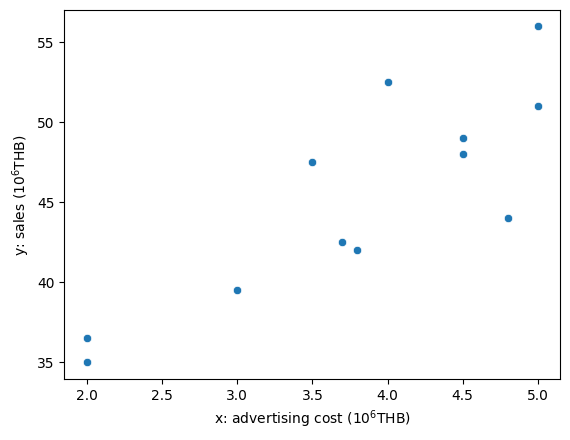

In [46]:
# 11.1
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/sale.csv")
sns.scatterplot(data=df,x='ad_cost',y='sale')

plt.xlabel('x: advertising cost ($10^6$THB)')
plt.ylabel('y: sales ($10^6$THB)')


In [47]:
# 11.2
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/sale.csv")
x = df.ad_cost
y = df.sale
info = stats.pearsonr(x,y)

print(f"r = {info.statistic:.3f} pval = {info.pvalue:.5f}")

r = 0.841 pval = 0.00061


In [48]:
# 11.3
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/sale.csv")
x = df.ad_cost
y = df.sale
info = stats.pearsonr(x,y)
t_crit_left = stats.t.ppf(0.05/2, df=12-2)
t_crit_right = stats.t.isf(0.05/2, df=12-2)
print(f"r = {info.statistic:.3f} pval = {info.pvalue:.5f} t_crit_left = {t_crit_left:.3f} t_crit_right = {t_crit_right:.3f}")
if(p_val>0.05):
  print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")

r = 0.841 pval = 0.00061 t_crit_left = -2.228 t_crit_right = 2.228
ปฎิเสธ H0


In [49]:
# 11.4
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/cosmetic.csv")
x = df.mk_share
y = df.payback_customer

info = stats.pearsonr(x,y)

r = info.statistic
t_cal = r/np.sqrt((1-r**2)/(14-2))
t_crit_left = stats.t.ppf(0.05/2, df=14-2)
t_crit_right = stats.t.isf(0.05/2,df=14-2)
print(f"t_cal = {t_cal:.3f} r = {r:.3f} pvalue = {info.pvalue} t_crit_left = {t_crit_left:.3f} t_crit_right = {t_crit_right:.3f}")

if(info.pvalue > 0.05):
    print("ยอมรับ H0")
else:
  print("ปฎิเสธ H0")

t_cal = 5.942 r = 0.864 pvalue = 6.793657739462203e-05 t_crit_left = -2.179 t_crit_right = 2.179
ปฎิเสธ H0


In [50]:
# 11.5
import statsmodels.api as sm
df = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/sale.csv")
x = df.ad_cost
y = df.sale
x_wconst = sm.add_constant(x)
lr = sm.OLS(y, x_wconst).fit()
y_hat = lr.predict(x_wconst)
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                   sale   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     24.17
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000608
Time:                        14:29:11   Log-Likelihood:                -31.561
No. Observations:                  12   AIC:                             67.12
Df Residuals:                      10   BIC:                             68.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.4655      4.170      6.107      0.0